In [1]:
import sys, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [2]:
with open("../data/data.pkl", "rb") as f:
    data = pickle.load(f)

X_train  = data["X_train"]
X_test   = data["X_test"]
y_train  = data["y_train"]
y_test   = data["y_test"]
FEATURES = data["FEATURES"]

## Linear SVM

In [ ]:
def make_linear_svm_tuning_pipeline(C=1.0):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote",  SMOTE(random_state=42, k_neighbors=5)),
        ("model",  LinearSVC(C=C, max_iter=2000, random_state=42)),
    ])

def make_linear_svm_pipeline(C=1.0):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote",  SMOTE(random_state=42, k_neighbors=5)),
        ("model",  CalibratedClassifierCV(LinearSVC(C=C, max_iter=2000, random_state=42), cv=3)),
    ])

param_grid_lin = {"model__C": [0.01, 0.1, 1, 10, 100]}

gs_lin = GridSearchCV(
    make_linear_svm_tuning_pipeline(),
    param_grid_lin,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
gs_lin.fit(X_train[FEATURES["C_full"]], y_train)

best_C_lin = gs_lin.best_params_["model__C"]
print(f"Best params (linear): {gs_lin.best_params_}")
print(f"Best CV ROC-AUC: {gs_lin.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params (linear): {'model__C': 0.01}
Best CV ROC-AUC: 0.8101


### Psych Questionnaire Features Only (Linear SVM)

In [4]:
pipe_a_lin = make_linear_svm_pipeline(C=best_C_lin)
pipe_a_lin.fit(X_train[FEATURES["A_psych"]], y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0...ndom_state=42)


In [5]:
y_train_pred = pipe_a_lin.predict(X_train[FEATURES["A_psych"]])
y_test_pred  = pipe_a_lin.predict(X_test[FEATURES["A_psych"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      7073
           1       0.38      0.73      0.50      1463

    accuracy                           0.75      8536
   macro avg       0.65      0.74      0.66      8536
weighted avg       0.84      0.75      0.77      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1769
           1       0.37      0.69      0.48       366

    accuracy                           0.74      2135
   macro avg       0.64      0.72      0.65      2135
weighted avg       0.83      0.74      0.77      2135



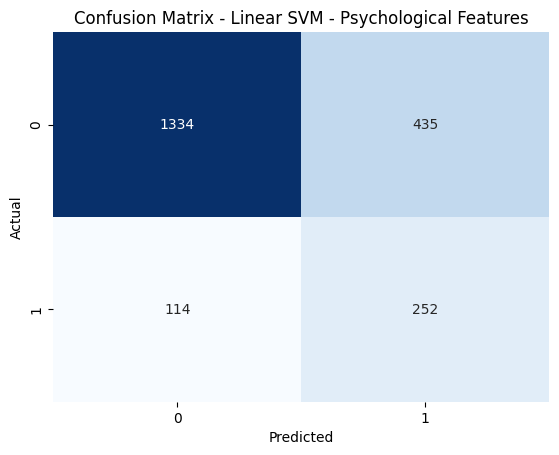

In [6]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM - Psychological Features")
plt.show()

In [7]:
y_prob_a_lin = pipe_a_lin.predict_proba(X_test[FEATURES["A_psych"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_a_lin):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_a_lin):.4f}")

ROC-AUC: 0.8103
PR-AUC:  0.5016


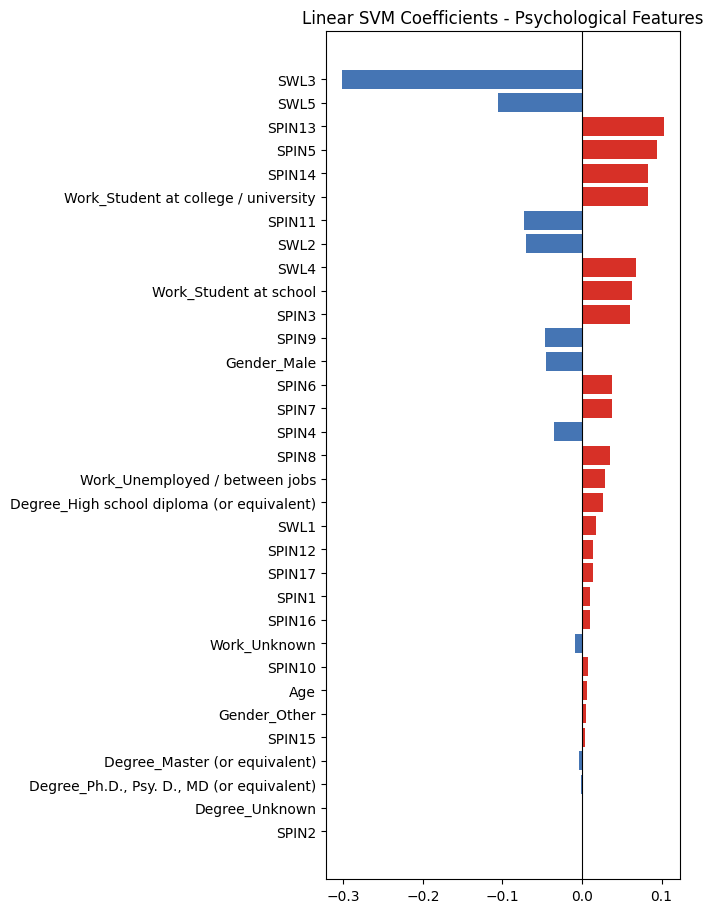

In [ ]:
lin_coef_a = np.mean(
    [c.estimator.coef_[0] for c in pipe_a_lin.named_steps["model"].calibrated_classifiers_],
    axis=0,
)
coef_df = (
    pd.DataFrame({"Feature": FEATURES["A_psych"], "Coefficient": lin_coef_a})
    .assign(abs_coef=lambda d: d["Coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
    .drop(columns="abs_coef")
)
colors = ["red" if c > 0 else "tab:blue" for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_df) * 0.28)))
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Linear SVM Coefficients - Psychological Features")
plt.tight_layout()
plt.show()

### Gaming Features Only (Linear SVM)

In [9]:
pipe_b_lin = make_linear_svm_pipeline(C=best_C_lin)
pipe_b_lin.fit(X_train[FEATURES["B_gaming"]], y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0...ndom_state=42)


In [10]:
y_train_pred = pipe_b_lin.predict(X_train[FEATURES["B_gaming"]])
y_test_pred  = pipe_b_lin.predict(X_test[FEATURES["B_gaming"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.88      0.63      0.73      7073
           1       0.24      0.59      0.34      1463

    accuracy                           0.62      8536
   macro avg       0.56      0.61      0.54      8536
weighted avg       0.77      0.62      0.66      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.88      0.63      0.74      1769
           1       0.25      0.58      0.35       366

    accuracy                           0.62      2135
   macro avg       0.56      0.61      0.54      2135
weighted avg       0.77      0.62      0.67      2135



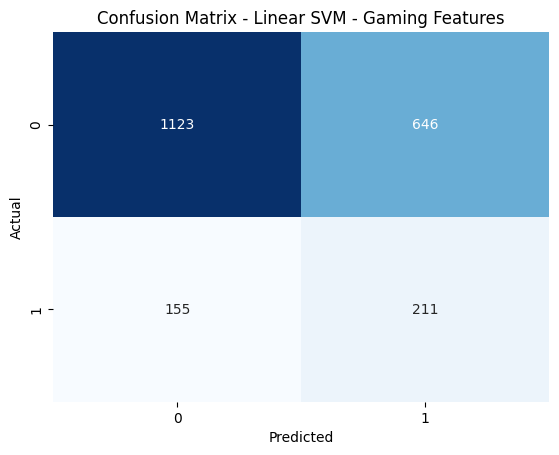

In [11]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM - Gaming Features")
plt.show()

In [12]:
y_prob_b_lin = pipe_b_lin.predict_proba(X_test[FEATURES["B_gaming"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_b_lin):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_b_lin):.4f}")

ROC-AUC: 0.6249
PR-AUC:  0.2850


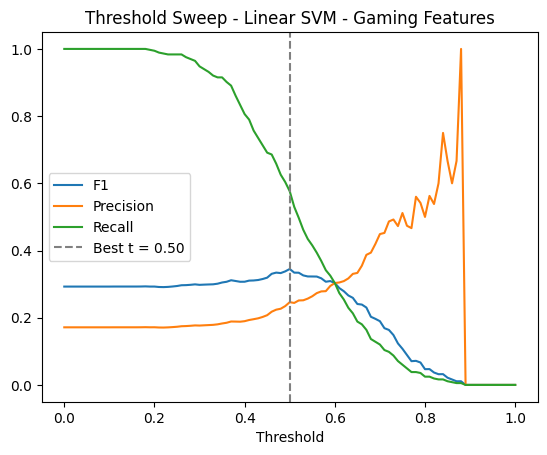

Best threshold (max F1): 0.50  →  F1 = 0.3451


In [13]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_b_lin >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - Linear SVM - Gaming Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

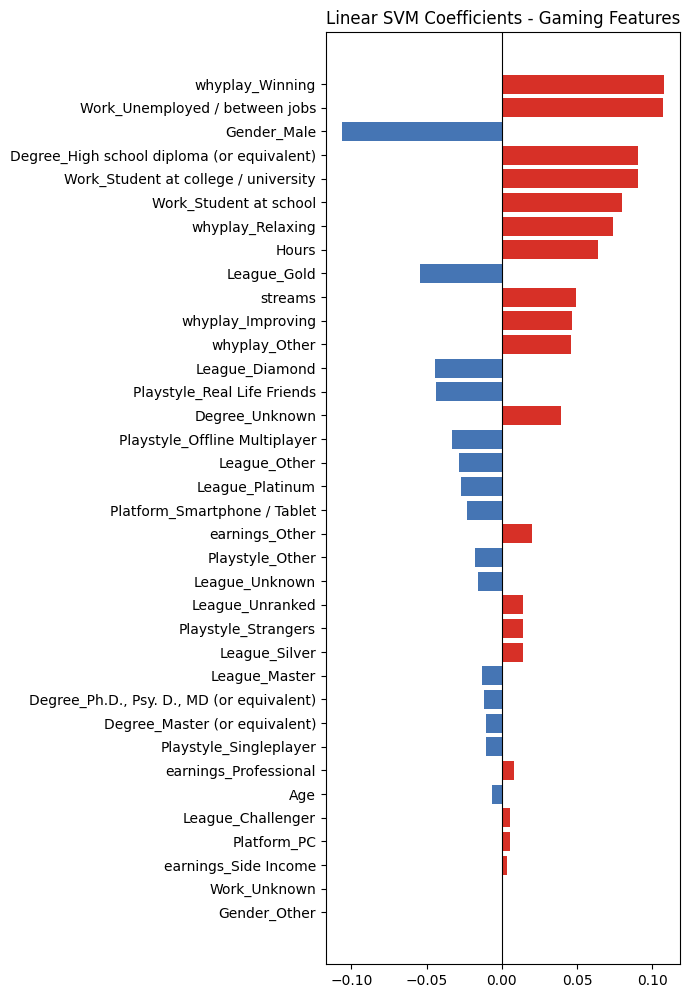

In [ ]:
lin_coef_b = np.mean(
    [c.estimator.coef_[0] for c in pipe_b_lin.named_steps["model"].calibrated_classifiers_],
    axis=0,
)
coef_df = (
    pd.DataFrame({"Feature": FEATURES["B_gaming"], "Coefficient": lin_coef_b})
    .assign(abs_coef=lambda d: d["Coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
    .drop(columns="abs_coef")
)
colors = ["red" if c > 0 else "tab:blue" for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_df) * 0.28)))
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Linear SVM Coefficients - Gaming Features")
plt.tight_layout()
plt.show()

### Combined Gaming and Psych Features (Linear SVM)

In [15]:
pipe_c_lin = make_linear_svm_pipeline(C=best_C_lin)
pipe_c_lin.fit(X_train[FEATURES["C_full"]], y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0...ndom_state=42)


In [16]:
y_train_pred = pipe_c_lin.predict(X_train[FEATURES["C_full"]])
y_test_pred  = pipe_c_lin.predict(X_test[FEATURES["C_full"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      7073
           1       0.38      0.73      0.50      1463

    accuracy                           0.75      8536
   macro avg       0.66      0.74      0.67      8536
weighted avg       0.84      0.75      0.78      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83      1769
           1       0.38      0.71      0.49       366

    accuracy                           0.75      2135
   macro avg       0.65      0.73      0.66      2135
weighted avg       0.83      0.75      0.77      2135



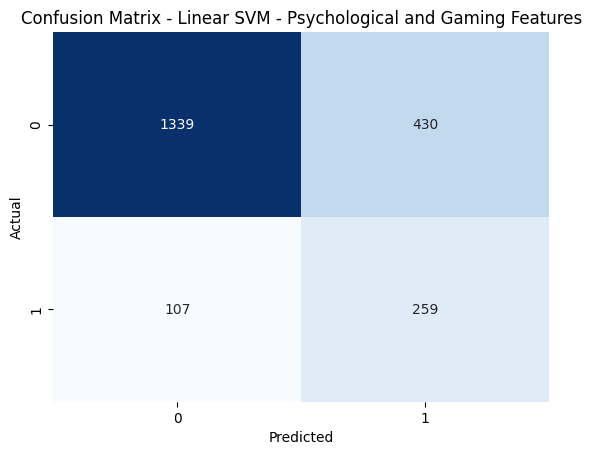

In [17]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM - Psychological and Gaming Features")
plt.show()

In [18]:
y_prob_c_lin = pipe_c_lin.predict_proba(X_test[FEATURES["C_full"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c_lin):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_c_lin):.4f}")

ROC-AUC: 0.8108
PR-AUC:  0.5086


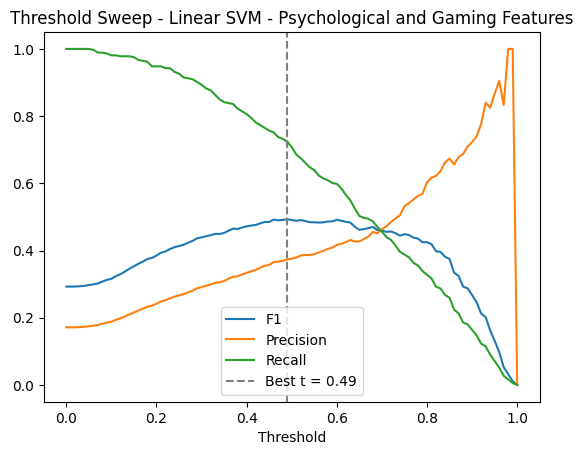

Best threshold (max F1): 0.49  →  F1 = 0.4930


In [19]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_c_lin >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - Linear SVM - Psychological and Gaming Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

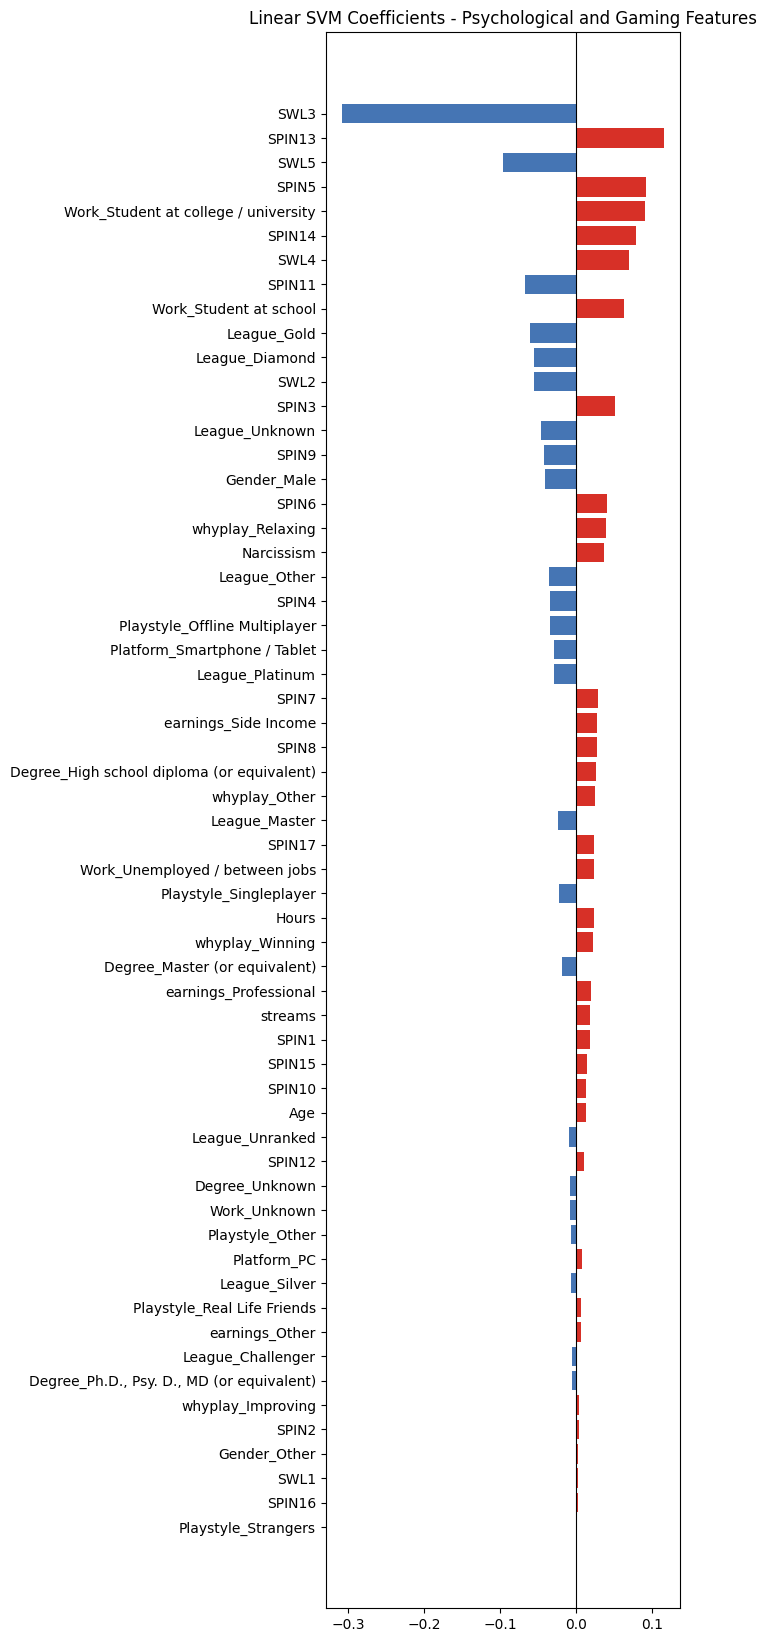

In [ ]:
lin_coef_c = np.mean(
    [c.estimator.coef_[0] for c in pipe_c_lin.named_steps["model"].calibrated_classifiers_],
    axis=0,
)
coef_df = (
    pd.DataFrame({"Feature": FEATURES["C_full"], "Coefficient": lin_coef_c})
    .assign(abs_coef=lambda d: d["Coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
    .drop(columns="abs_coef")
)
colors = ["red" if c > 0 else "tab:blue" for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_df) * 0.28)))
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Linear SVM Coefficients - Psychological and Gaming Features")
plt.tight_layout()
plt.show()

## RBF SVM

In [21]:
def make_rbf_svm_tuning_pipeline(C=1.0):
    """Fast pipeline for grid search — probability=False avoids Platt scaling overhead."""
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote",  SMOTE(random_state=42, k_neighbors=5)),
        ("model",  SVC(kernel="rbf", C=C, gamma="scale", random_state=42)),
    ])

def make_rbf_svm_pipeline(C=1.0):
    """Final pipeline with predict_proba."""
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote",  SMOTE(random_state=42, k_neighbors=5)),
        ("model",  SVC(kernel="rbf", C=C, gamma="scale", probability=True, random_state=42)),
    ])

param_grid_rbf = {"model__C": [0.1, 1, 10]}

gs_rbf = GridSearchCV(
    make_rbf_svm_tuning_pipeline(),
    param_grid_rbf,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
gs_rbf.fit(X_train[FEATURES["C_full"]], y_train)

best_C_rbf = gs_rbf.best_params_["model__C"]
print(f"Best params (rbf): {gs_rbf.best_params_}")
print(f"Best CV ROC-AUC: {gs_rbf.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (rbf): {'model__C': 0.1}
Best CV ROC-AUC: 0.7913


### Psych Questionnaire Features Only (RBF SVM)

In [22]:
pipe_a_rbf = make_rbf_svm_pipeline(C=best_C_rbf)
pipe_a_rbf.fit(X_train[FEATURES["A_psych"]], y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1


In [23]:
y_train_pred = pipe_a_rbf.predict(X_train[FEATURES["A_psych"]])
y_test_pred  = pipe_a_rbf.predict(X_test[FEATURES["A_psych"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      7073
           1       0.40      0.75      0.52      1463

    accuracy                           0.76      8536
   macro avg       0.67      0.76      0.68      8536
weighted avg       0.84      0.76      0.79      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1769
           1       0.37      0.69      0.48       366

    accuracy                           0.74      2135
   macro avg       0.64      0.72      0.65      2135
weighted avg       0.83      0.74      0.77      2135



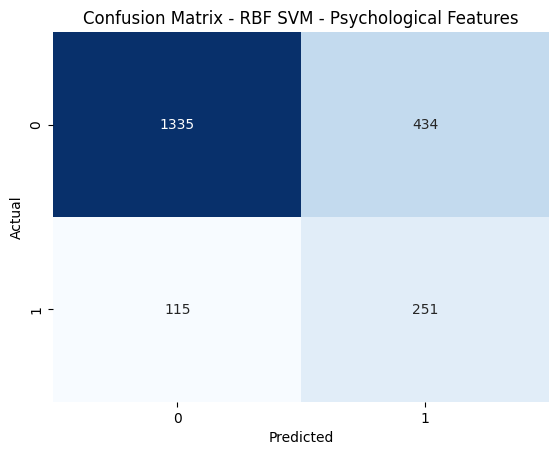

In [24]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RBF SVM - Psychological Features")
plt.show()

In [25]:
y_prob_a_rbf = pipe_a_rbf.predict_proba(X_test[FEATURES["A_psych"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_a_rbf):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_a_rbf):.4f}")

ROC-AUC: 0.7974
PR-AUC:  0.4138


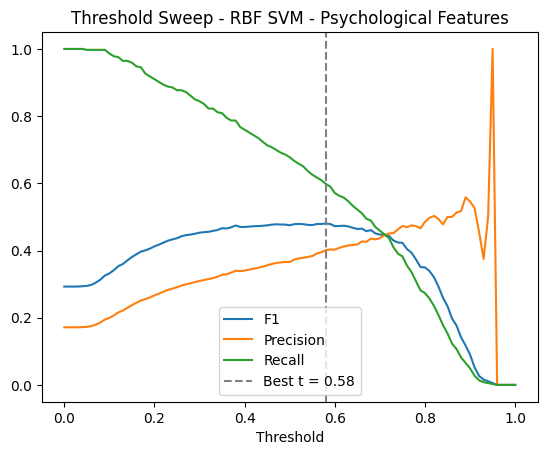

Best threshold (max F1): 0.58  →  F1 = 0.4803


In [26]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_a_rbf >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - RBF SVM - Psychological Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

### Gaming Features Only (RBF SVM)

In [27]:
pipe_b_rbf = make_rbf_svm_pipeline(C=best_C_rbf)
pipe_b_rbf.fit(X_train[FEATURES["B_gaming"]], y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1


In [28]:
y_train_pred = pipe_b_rbf.predict(X_train[FEATURES["B_gaming"]])
y_test_pred  = pipe_b_rbf.predict(X_test[FEATURES["B_gaming"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.88      0.69      0.77      7073
           1       0.27      0.57      0.37      1463

    accuracy                           0.67      8536
   macro avg       0.58      0.63      0.57      8536
weighted avg       0.78      0.67      0.71      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      1769
           1       0.24      0.50      0.33       366

    accuracy                           0.65      2135
   macro avg       0.56      0.59      0.55      2135
weighted avg       0.76      0.65      0.69      2135



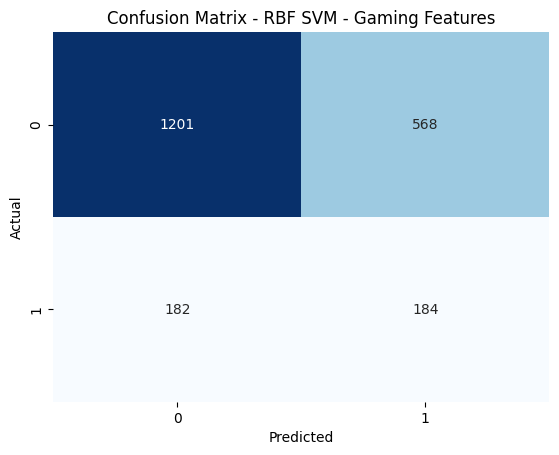

In [29]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RBF SVM - Gaming Features")
plt.show()

In [30]:
y_prob_b_rbf = pipe_b_rbf.predict_proba(X_test[FEATURES["B_gaming"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_b_rbf):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_b_rbf):.4f}")

ROC-AUC: 0.6143
PR-AUC:  0.2487


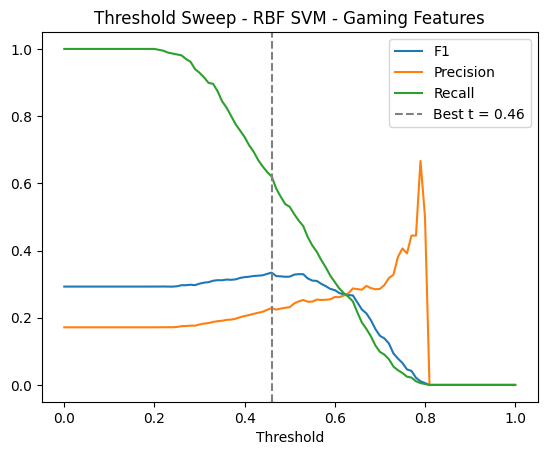

Best threshold (max F1): 0.46  →  F1 = 0.3343


In [31]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_b_rbf >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - RBF SVM - Gaming Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

### Combined Gaming and Psych Features (RBF SVM)

In [32]:
pipe_c_rbf = make_rbf_svm_pipeline(C=best_C_rbf)
pipe_c_rbf.fit(X_train[FEATURES["C_full"]], y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1


In [33]:
y_train_pred = pipe_c_rbf.predict(X_train[FEATURES["C_full"]])
y_test_pred  = pipe_c_rbf.predict(X_test[FEATURES["C_full"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7073
           1       0.41      0.76      0.53      1463

    accuracy                           0.77      8536
   macro avg       0.67      0.77      0.69      8536
weighted avg       0.85      0.77      0.79      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1769
           1       0.36      0.66      0.47       366

    accuracy                           0.74      2135
   macro avg       0.64      0.71      0.65      2135
weighted avg       0.82      0.74      0.77      2135



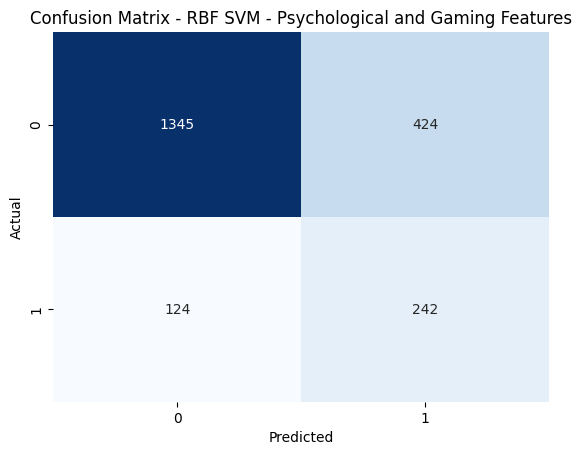

In [34]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RBF SVM - Psychological and Gaming Features")
plt.show()

In [35]:
y_prob_c_rbf = pipe_c_rbf.predict_proba(X_test[FEATURES["C_full"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c_rbf):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_c_rbf):.4f}")

ROC-AUC: 0.7931
PR-AUC:  0.4092


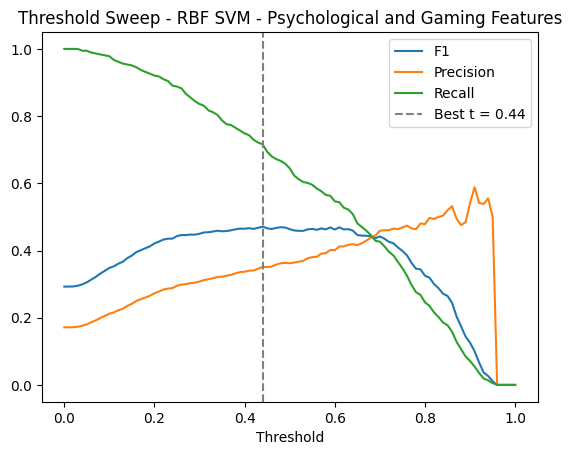

Best threshold (max F1): 0.44  →  F1 = 0.4712


In [36]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_c_rbf >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - RBF SVM - Psychological and Gaming Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")